In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/Users/mala/Documents/AI_engineer/jobmatch-ai/data/raw/Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
df.shape

(2484, 4)

In [4]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [6]:
df['Category'].value_counts

<bound method IndexOpsMixin.value_counts of 0             HR
1             HR
2             HR
3             HR
4             HR
          ...   
2479    AVIATION
2480    AVIATION
2481    AVIATION
2482    AVIATION
2483    AVIATION
Name: Category, Length: 2484, dtype: object>

<Axes: xlabel='Category'>

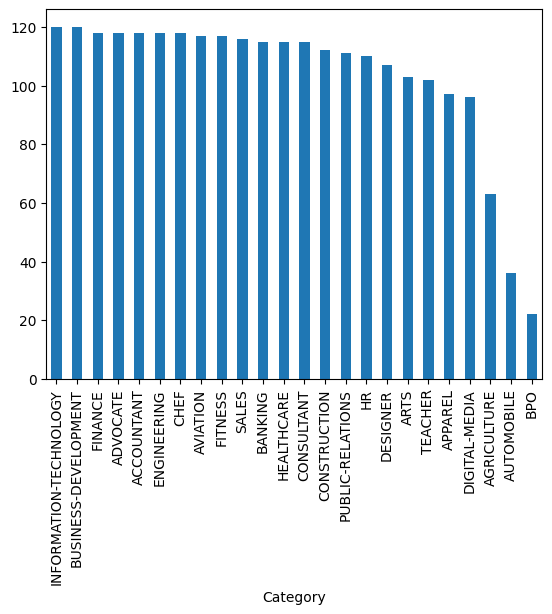

In [7]:
df['Category'].value_counts().plot(kind='bar')

In [8]:
print("jumlah baris: ", df.shape[0])
print("jumlah kolom: ", df.shape[1])

jumlah baris:  2484
jumlah kolom:  4


In [9]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [10]:
print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows:  0


In [11]:
print("Duplicate resume: ", df["Resume_str"].duplicated().sum())

Duplicate resume:  2


In [12]:
df["resume_length"] = df["Resume_str"].str.len()
df["resume_length"].describe()

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: resume_length, dtype: float64

<Axes: title={'center': 'Resume Length Distribution'}, ylabel='Frequency'>

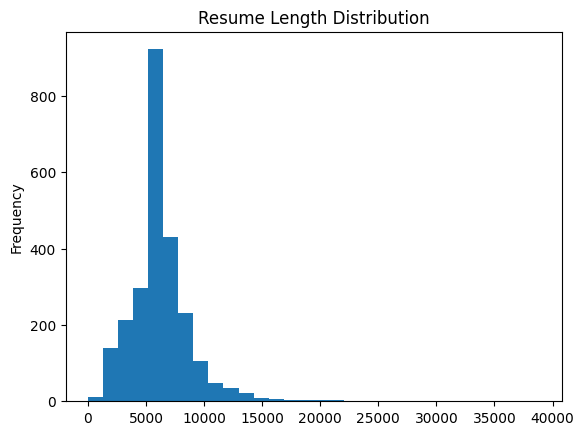

In [13]:
df["resume_length"].plot(
    kind="hist",
    bins=30,
    title="Resume Length Distribution"
)

In [14]:
df.nsmallest(10, "resume_length")[["Category", "resume_length"]]

,Category,resume_length
656,BUSINESS-DEVELOPMENT,21
1931,CONSTRUCTION,881
130,DESIGNER,985
1102,SALES,995
1049,SALES,1033
1400,CHEF,1130
153,DESIGNER,1181
1852,ACCOUNTANT,1210
1039,SALES,1212
2322,ARTS,1272


In [15]:
df.nlargest(10, "resume_length")[["Category", "resume_length"]]

,Category,resume_length
1366,CHEF,38842
2111,PUBLIC-RELATIONS,35933
2007,CONSTRUCTION,30055
94,HR,24834
1817,ACCOUNTANT,24695
1258,DIGITAL-MEDIA,24500
1356,AUTOMOBILE,22032
1960,CONSTRUCTION,21675
683,HEALTHCARE,21316
547,ADVOCATE,20975


In [16]:
category_counts = df["Category"].value_counts()
print(category_counts)

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [17]:
print("Kategori:", df["Category"].nunique())
print("Kategori terbanyak:", category_counts.index[0])
print("Jumlah:", category_counts.iloc[0])
print("Kategori tersedikit:", category_counts.index[-1])
print("Jumlah:", category_counts.iloc[-1])

Kategori: 24
Kategori terbanyak: INFORMATION-TECHNOLOGY
Jumlah: 120
Kategori tersedikit: BPO
Jumlah: 22


In [18]:
# cek missing value -> isnull() 
# di jumlahkan dengan sum()
df.isnull().sum()

ID               0
Resume_str       0
Resume_html      0
Category         0
resume_length    0
dtype: int64

In [19]:
print("Duplicate rows: ", df.duplicated().sum())
print("Duplicated resumes: ", df['Resume_str'].duplicated().sum())

Duplicate rows:  0
Duplicated resumes:  2


In [20]:
# describe -> untuk nampilkan detail sebuah kolom
df["resume_length"] = df["Resume_str"].str.len()
df["resume_length"].describe()

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: resume_length, dtype: float64

In [21]:
# ambil 10 CV dengan resume_length paling kecil (resume_length berarti tabel primary 
# yg mau di urutkan dari terkecil)
# Ambil 10 CV paling pendek, kemudian tampilkan Category, resume_length, dan Resume_str.

df.nsmallest(10, "resume_length")[["Category", "resume_length", "Resume_str"]]

,Category,resume_length,Resume_str
656,BUSINESS-DEVELOPMENT,21,
1931,CONSTRUCTION,881,CONSTRUCTION WORKER Highlig...
130,DESIGNER,985,GRAPHIC DESIGNER Expe...
1102,SALES,995,SALES ASSOCIATE Summary My g...
1049,SALES,1033,SALES ASSOCIATE Summary Moti...
1400,CHEF,1130,SUSHI CHEF Executive Profile ...
153,DESIGNER,1181,FLORAL DESIGNER Skills B...
1852,ACCOUNTANT,1210,ACCOUNTANT Summary Accountan...
1039,SALES,1212,SALES ASSOCIATE Experience ...
2322,ARTS,1272,CERTIFIED CUSTOM FRAMER Q...


In [22]:
df.nlargest(10, "resume_length")[["Category", "resume_length", "Resume_str"]]

,Category,resume_length,Resume_str
1366,CHEF,38842,CHEF Credentials National R...
2111,PUBLIC-RELATIONS,35933,BARTENDER Experience B...
2007,CONSTRUCTION,30055,PROJECT MANGER/LEAD SUPER P...
94,HR,24834,HR SPECIALIST (INFORMATION SYSTEMS) ...
1817,ACCOUNTANT,24695,ACCOUNTANT Summary Fina...
1258,DIGITAL-MEDIA,24500,"CHIEF SYSTEM ARCHITECT, SVP SYSTEM IN..."
1356,AUTOMOBILE,22032,SENIOR ARCHITECT - MDM Prof...
1960,CONSTRUCTION,21675,DIRECTOR OF SHIP CONSTRUCTION E...
683,HEALTHCARE,21316,HEALTHCARE PROVIDER Profess...
547,ADVOCATE,20975,LEVEL 2 CRITICAL PLATFORM SUPPORT ENG...


In [23]:
# keep=False untuk melihat kedua baris yang sama, bukan hanya duplikat keduanya.
duplicates = df[df["Resume_str"].duplicated(keep=False)]
duplicates[["ID", "Category", "Resume_str"]]

,ID,Category,Resume_str
1490,19147603,FINANCE,FINANCE OFFICER Professional ...
1509,28398216,FINANCE,FINANCE OFFICER Professional ...
2444,16850314,AVIATION,STOREKEEPER II Professional Sum...
2483,37473139,AVIATION,STOREKEEPER II Professional Sum...


penjelasan program pada line "duplicates = df[df["Resume_str"].duplicated(keep=False)]"

misal kita punya 5 baris data
| Baris | CV                                                  |
| ----- | --------------------------------------------------- |
| 1     | `Saya adalah software engineer dengan skill Python` |
| 2     | `Saya adalah HR dengan pengalaman recruitment`      |
| 3     | `Saya adalah data analyst dengan skill SQL`         |
| 4     | `Saya adalah software engineer dengan skill Python` |
| 5     | `Saya adalah designer dengan skill Photoshop`       |

**baris 1 dan baris 4 merupakan duplicate**

fungsi *duplicate()* akan ngecek gini :
baris 1 -> "Saya adalah software .... " -> Apakah saya pernah melihat teks ini sebelumnya? > belum -> maka *False*
baris 2 -> "Saya adalah HR dengan ..." -> Apakah saya pernah melihat teks ini sebelumnya? > belum -> maka *False*
baris 3 -> "Saya adalah data analyst .." -> Apakah saya pernah melihat teks ini sebelumnya? > belum -> maka *False*
baris 4 -> "Saya adalah software .... " -> Apakah saya pernah melihat teks ini sebelumnya? > belum -> maka **True**
baris 5 -> "Saya adalah designer .." -> Apakah saya pernah melihat teks ini sebelumnya? > belum -> maka *False*

**maka :**
Baris 1 → False
Baris 2 → False
Baris 3 → False
Baris 4 → True
Baris 5 → False

Lalu apa gunanya *"Keep = False"* ?
- secara default, kalo pake fungsi **duplicated()** akan menganggap kemunculan pertama atau baris pertama sebagai bukan *duplicate*
- fungsi *keep = False* adalah menandai semua baris yang punya pasangan data yang sama
- maka hasilnya adalah 
**Baris 1 → True**
Baris 2 → False
Baris 3 → False
**Baris 4 → True**
Baris 5 → False

*Kenapa ini penting ?*
misal kita punya :

CV A → Information Technology
CV A → Information Technology

bisa saja waktu *training data* = CV A
dan waktu *test data* = CV A (datanya sama dengan training data)

Karena model telah melihat CV A waktu training sehingga performanya menjadi bagus waktu test data which is bukan kemampuan dia yang sebenarnya **(data leakage)**

In [24]:
duplicates[["ID", "Category", "Resume_str"]].sort_values("Resume_str")

,ID,Category,Resume_str
1490,19147603,FINANCE,FINANCE OFFICER Professional ...
1509,28398216,FINANCE,FINANCE OFFICER Professional ...
2444,16850314,AVIATION,STOREKEEPER II Professional Sum...
2483,37473139,AVIATION,STOREKEEPER II Professional Sum...


In [25]:
# Menghapus duplicate
df = df.drop_duplicates(subset = "Resume_str", keep="first")
print("jumlah data setelah menghapus duplicate: ", len(df))

jumlah data setelah menghapus duplicate:  2482


In [26]:
# cek duplicate lagi
df["Resume_str"].duplicated().sum()

0

In [27]:
# Menghapus CV yang terlalu pendek
# df.loc -> berfungsi untuk mencari lokasi baris sebuah data tertentu
df.loc[df["resume_length"] == 21, ["ID","Category", "resume_length", "Resume_str"]]

,ID,Category,resume_length,Resume_str
656,12632728,BUSINESS-DEVELOPMENT,21,


In [28]:
# Hapus cv pendek itu dengan menggunakan copy()
# copy() -> berfungsi untuk membuat salinan dataframe baru dan terpisah dari DF aslinya
# tujuannya supaya tidak mengubah isi data
df = df[df["resume_length"] > 21].copy()
print("jumlah data: ", len(df))

jumlah data:  2481


In [29]:
df["resume_length"].min()

881

**Preprocessing Teks h1**

In [30]:
print(df["Resume_str"].iloc[0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

**Alur preprocessing**

Raw Resume
     ↓
Lowercase
     ↓
Normalize whitespace
     ↓
Remove unnecessary punctuation
     ↓
Clean text
     ↓
TF-IDF
     ↓
ML Model

tidak melakukan : *menghapus stopwords*, *stemming*, *lemmatization*

karena ada kata2 penting seperti :

customer service
human resources
data analysis
financial management

In [31]:
# clean the data
import re

def clean_resume(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text) #mengubah line break dan spasi berlebihan menjadi 1 spasi
    text = re.sub(r"[^\w\s+#.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip() #merapikan spasi setelah punctuation dihapus

    return text

**Penjelasan kodingan**

*re.sub(r"[^a-z0-9\s]", " ", text)* -> akan menghapus karakter seperti c++, c#, .NET

misal c++ developer akan diubah menjadi c developer. *kurang ideal* karena nama teknologi penting dalam CV

maka pakai versi lebih aman, yaitu 

**Normalisasi whitespace**
text = re.sub(r"\s+", " ", text)
    
**Hapus punctuation yang tidak diperlukan,**
**tetapi pertahankan karakter penting dalam istilah teknis**
text = re.sub(r"[^\w\s+#.]", " ", text)
    
**Rapikan spasi**
text = re.sub(r"\s+", " ", text).strip()

In [32]:
df["clean_text"] = df["Resume_str"].apply(clean_resume)

In [33]:
print("BEFORE:\n")
print(df["Resume_str"].iloc[0][:1000])

print("\n\nAFTER:\n")
print(df["clean_text"].iloc[0][:1000])

BEFORE:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, l

## Proses TF - IDF

In [34]:
df["clean_text"].isnull().sum()

0

In [35]:
(df["clean_text"].str.len() == 0).sum()

0

penjelasan *(df["clean_text"].str.len() == 0).sum()*

- Tanda Kurung () di awal dan akhir itu digunakan untuk mengelompokkan hasil operasi sebelum .sum() dijalankan.

- fungsi line ini *df["clean_text"].str.len()* menghitung panjang teks yang sudah di clean tadi, misal hasilnya adalah 
0    5000
1    3500
2    4200

- karena kita mau cari *panjang teks = 0*, maka hasilnya akan berupa true dan false
- kemudian dihitung berapa nilai *True* nya dengan *sum()*

In [36]:
df["clean_text"].str.len().describe()

count     2481.000000
mean      5806.530028
std       2627.144937
min        673.000000
25%       4717.000000
50%       5421.000000
75%       6699.000000
max      34763.000000
Name: clean_text, dtype: float64

**TF-IDF** -> cara untuk mengubah teks menjadi angka supaya bisa diproses oleh model machine learning seperti Logistic Regression, SVM, atau Random Forest.

**TF-IDF memberikan bobot lebih tinggi kepada kata yang penting untuk suatu CV, tetapi relatif jarang muncul di seluruh kumpulan CV.**

Kenapa perlu TF-IDF ?

karena ML tidak bisa langsung memahami "Python SQL machine learning NLP". Mereka membutuhkan angka.
*jadi strukturnya adalah*

CV
↓
Teks
↓
Representasi angka
↓
ML Model

**TF-IDF adalah salah satu cara sederhana dan populer untuk melakukan representasi tersebut.**

cara kerja pembobotan-nya:
- misal kita punya 3 CV yang mengandung kata-kata ini "Python machine learning NLP Python, "Python SQL statistics Python" dan "Human resources recruitment communication"

- kata *python* muncul di CV 1 dan CV 2
- kata *NLP* hanya muncul di CV 1
- kata *recruitment* hanya muncul di CV 3

*TF (Term Frequency)* mengukur **Seberapa sering suatu kata muncul dalam satu dokumen?**

misal : Python machine learning Python Python
- jumlah kata = 5
- jumlah kata python muncul = 3
- maka rumus TF adalah $TF(python) = 3/5 = 0.6$
- sedangkan kata machine muncul = 1
- maka $TF(machine) = 1/5 = 0.2$

**Jadi semakin sering kata muncul dalam satu CV, TF-nya semakin besar.**

Namun ada masalah,

Misal ada 5 CV yang menyebutkan kata *experience*. apakah kata experience berguna untuk membedakan mana yang AI engineer, GR, finance dan sebagainya? Tidak.

**Kalau sebuah kata muncul hampir di semua dokumen, kata tersebut kurang diskriminatif.**

disinilah fungsi *IDF*

# IDF = Inverse Document Frequency

IDF melihat: *Seberapa jarang sebuah kata muncul di seluruh kumpulan dokumen?*

Misal kita punya 100 CV dan kata *experience* muncul di 90 CV. Maka skor nilai **IDFnya rendah**. Jika ada kata yang jarang muncul -> **IDF Tinggi**. 

rumusnya adalah $IDF(t) = log(N/df(t))$

- N = jumlah seluruh dokumen
- (df(t)) = jumlah dokumen yang mengandung term (t)

Maka rumus TF-IDF = *TFIDF(t,d)= TF(t,d) × IDF(t)*

**TF -> Seberapa sering kata ini muncul di CV ini?**
**IDF -> Seberapa jarang kata ini muncul di seluruh CV?**

hasilnya akan seperti ini :

              Python   SQL   NLP   PyTorch   Recruitment   Finance
CV 1           0.32    0     0.41   0.57        0            0

**pipelinenya akan menjadi seperti ini:**

Raw CV
  ↓
Cleaning
  ↓
clean_text
  ↓
TF-IDF
  ↓
Numerical Features
  ↓
ML Model
  ↓
Predicted Category

**salah satu keterbatasan TF-IDF adalah**
- dia tidak benar-benar memahami bahwa *Machine Learning* berhubungan dengan *Artificial Intelligence*
- tapi ia dapat menganggap memiliki hubungan jika mengandung kata yang sama, misal *Python Developer* dengan *Python Developer*

# Train/Validation/Test Split.

2481 CV -> *Training* → model belajar | *Validation* → memilih/tuning model | *Test*→ evaluasi final

70% Training
15% Validation
15% Test

Training    ≈ 1737 CV
Validation  ≈ 372 CV
Test        ≈ 372 CV

**Training:**

Data yang benar-benar digunakan model untuk belajar.

**Validation:**

Data untuk membantu kita memilih konfigurasi/model yang lebih baik.

**Test:**

Data yang disimpan sampai akhir untuk mengetahui performa model pada data yang belum pernah digunakan selama pengembangan.

                    2481 CV
                       │
                    SPLIT
                       │
        ┌──────────────┼──────────────┐
        ▼              ▼              ▼
     TRAIN           VALIDATION       TEST
        │              │              │
        ▼              │              │
   TF-IDF FIT           │              │
        │              │              │
        ├──────────────┼──────────────┤
        ▼              ▼              ▼
      TF-IDF          TF-IDF         TF-IDF
      TRANSFORM       TRANSFORM      TRANSFORM

- tidak semua bisa di TF-IDF saat training, karna akan terjadi *data leakage*
- *fit* adalah proses belajar parameter TF-IDF dari data. fit() -> Belum mengubah teks menjadi angka. **(belajar kamus)**
- hanya mempelajari kata apa saja yang ada, document frequency setiap kata, vocabulary, dan nilai IDF setiap kata
- *transform()* -> vocabulary dan IDF yang sudah dipelajari digunakan untuk mengubah teks menjadi angka. **(menggunakan kamus)**
- *fit_transform()* -> belajar parameter + langsung mengubah data menjadi vector. **(belajar kamus + langsung menerjemahkan teks.)**

**TRAIN**
X_train -> fit_transform() -> X_train_tfidf


**VALIDATION**
X_val -> transform() -> X_val_tfidf


**TEST**
X_test -> transform() -> X_test_tfidf

**split dataset sebelum TF-IDF: kita ingin vocabulary dan nilai IDF hanya dipelajari dari data training.**

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X = df["clean_text"]
Y = df["Category"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    Y,
    test_size = 0.30,
    random_state = 42,
    stratify = Y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.50,
    random_state = 42,
    stratify = y_temp
)

print("Training: ", len(X_train))
print("Validation: ", len(X_val))
print("Test: ", len(X_test))

Training:  1736
Validation:  372
Test:  373


# Penjelasan kodingan split

X -> **berisikan informasi yang akan digunakan model untuk membuat prediksi.**
Y -> **jawaban yang ingin dipelajari model.** (target prediksi)

jadi, model akan mempelajari CV (var X) kemudian memprediksi category-nya (var Y)

- test_size = 0.30 -> artinya 30% data dipisah menjadi **temp**
- dari 2481, **70% -> X_train / y_train** | **30% -> X_temp / y_temp**

- X_train -> CV yang digunakan untuk melatih model
- X_temp -> data sementara yg belum kita tentukan akan menjadi : Validation atau Test.

**Kemudian split X_temp yang 30% itu.**

30% temp = 50% Validation dan 50% Test.

karena 30% * 50% = 15%, maka

70% -> training | 15% -> Validation | 15% -> Test

# random_state = 42
digunakan supaya pembagian **data reproducible**.
setiap kali menjalankan train_test_split, hasil pembagiannya bisa beda. Hari ini bisa jadi CV A-> Train CV B -> Test. besoknya bisa jadi CV A -> test | CV B -> train.

# Stratify
berguna supaya split tetap dapat mempertahankan proporsinya. karena bisa jadi karena random split, pembagiannya kurang representatif.

In [39]:
# representasi TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range=(1,2)
)

# max_feature = 5000 -> menggunakan 5000 fitur
# misal setiap TF-IDF per CV adalah 50.000 kata/frasa\
# maka setiap cv akan di representasikan seperti ini CV → [0, 0, 0, 0.21, 0, ..., 0.08] sampai 50.000
# Padahal banyak kata tersebut mungkin tidak terlalu berguna untuk membedakan kategori pekerjaan.
# jadi, Gunakan maksimal 5.000 fitur yang paling relevan berdasarkan TF-IDF.


# ngram_range = (1,2) -> menggunakan bigram (2 kata berurutan), model akan melihat frasa machine learning
# bukan machine dan learning.

In [40]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

fit → TF-IDF belajar vocabulary dari data training.

transform → validation dan test hanya menggunakan vocabulary yang sudah dipelajari.

jadi :

**TRAIN** = X_train -> fit + transform -> X_train_tfidf


**VALIDATION** =  X_val -> transform saja -> X_val_tfidf


**TEST** = X_test -> transform saja -> X_test_tfidf

In [41]:
print("Training shape   :", X_train_tfidf.shape)
print("Validation shape :", X_val_tfidf.shape)
print("Test shape       :", X_test_tfidf.shape)

Training shape   : (1736, 5000)
Validation shape : (372, 5000)
Test shape       : (373, 5000)


In [42]:
# Train model pertama
# Logistic Regression untuk baseline

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter = 1000,
    random_state=42
)

In [43]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [44]:
y_val_pred = model.predict(X_val_tfidf)

In [45]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(y_val, y_val_pred)
print("validation accuracy: ", val_accuracy)

validation accuracy:  0.6129032258064516


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.61      0.82      0.70        17
              ADVOCATE       0.26      0.47      0.33        17
           AGRICULTURE       1.00      0.20      0.33        10
               APPAREL       0.62      0.33      0.43        15
                  ARTS       0.50      0.25      0.33        16
            AUTOMOBILE       0.00      0.00      0.00         6
              AVIATION       0.91      0.59      0.71        17
               BANKING       0.64      0.53      0.58        17
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.50      0.89      0.64        18
                  CHEF       0.88      0.82      0.85        17
          CONSTRUCTION       0.79      0.65      0.71        17
            CONSULTANT       0.33      0.18      0.23        17
              DESIGNER       0.92      0.75      0.83        16
         DIGITAL-MEDIA       0.70      

/Users/mala/Documents/AI_engineer/jobmatch-ai/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mala/Documents/AI_engineer/jobmatch-ai/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mala/Documents/AI_engineer/jobmatch-ai/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [47]:
y_train_pred = model.predict(X_train_tfidf)

In [48]:
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy  :", train_accuracy)
print("Validation Accuracy:", val_accuracy)

Training Accuracy  : 0.8035714285714286
Validation Accuracy: 0.6129032258064516


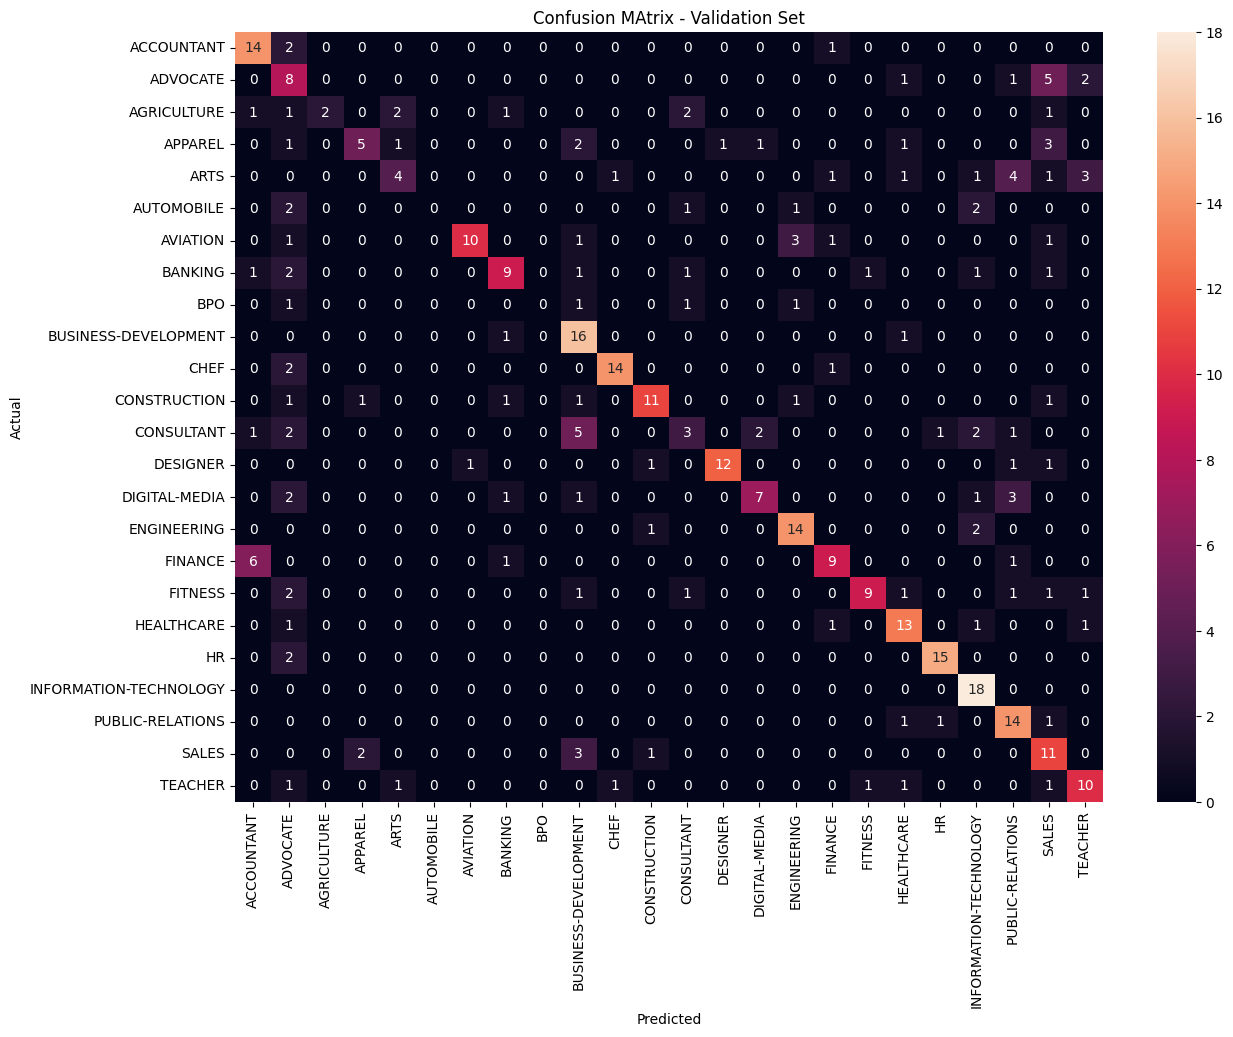

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(14,10))
sns.heatmap(
    cm,
    annot = True,
    fmt ="d",
    xticklabels = model.classes_,
    yticklabels = model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion MAtrix - Validation Set")
plt.show()


di matrix ini:
- baris (Actual) = kategori sebenarnya
- kolom (predicted) = kategori yang diprediksi model
- diagonal = prediksi yang benar
- di luar diagonal = prediksi yang salah

contoh cara baca matrixnya:
- ACCOUNTANT: 14 CV berhasil dikenali sebagai ACCOUNTANT.
- HR: 15 CV berhasil dikenali dengan benar.

ADVOCATE hanya 8 yang benar, sementara beberapa CV-nya masuk ke kategori lain.

**Kesimpulan**
- Model mengalami overfitting, karena training accuracy jauh lebih tinggi daripada validation accuracy.
- nilai c yang dipakai adalah 1.0

**Note**
- nilai C -> berfungsi untuk mengatur seberapa kuat regularisasi yang diberikan kepada model
- jika *nilai C besar*, model diberi kebebasan lebih besar untuk menyesuaikan diri dengan data training sehingga *overfitting menaik*
- jika *nilai C kecil*, regularisasi lebih kuat sehingga model lebih dibatasi, model hanya berfokus pada pola yang lebih umum sehingga resiko *overfitting menurun*

- gap antara acc training dan acc validation sebesar 19%

In [50]:
# mencoba mengurangi overfitting dengan tuning nilai C pada Logistic Regression
model_c01 = LogisticRegression(
    C=0.1,
    max_iter = 1000,
    random_state = 42
)
model_c01.fit(X_train_tfidf, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

In [51]:
# evaluasi training & validasi

y_train_pred_c01 = model_c01.predict(X_train_tfidf)
y_val_pred_c01 = model_c01.predict(X_val_tfidf)

train_acc_c01 = accuracy_score(y_train, y_train_pred_c01)
val_acc_c01 = accuracy_score(y_val, y_val_pred_c01)

print("Training Accuracy: ", train_acc_c01)
print("Validation Accuracy: ", val_acc_c01)

Training Accuracy:  0.6330645161290323
Validation Accuracy:  0.5510752688172043


- Model mengalami **Underfitting**
- ini karena validation accuracy terlalu rendah meskipun gap antara acc training dan acc validation sebesar 8%

model dianggap tidak overfitting dan underfitting jika:
- performa training cukup bagus
- performa validation yang baik
- gap yang tidak terlalu besar

In [52]:
# mencoba dengan nilai c = 0.5
model_c05 = LogisticRegression(
    C = 0.5,
    max_iter = 1000,
    random_state = 42
)
model_c05.fit(X_train_tfidf, y_train)

LogisticRegression(C=0.5, max_iter=1000, random_state=42)

In [53]:
y_train_pred_c05 = model_c05.predict(X_train_tfidf)
y_val_pred_c05 = model_c05.predict(X_val_tfidf)

train_acc_c05 = accuracy_score(y_train, y_train_pred_c05)
val_acc_c05 = accuracy_score(y_val, y_val_pred_c05)

print("Training Accuracy: ", train_acc_c05)
print("Validation Accuracy: ", val_acc_c05)

Training Accuracy:  0.7355990783410138
Validation Accuracy:  0.5833333333333334


- lebih seimbang daripada 0.1, tetapi masih lebih buruk dari baseline
- memiliki gap 15.23%
- termasuk underfitting

In [54]:
model_c07 = LogisticRegression(
    C = 0.7,
    max_iter = 1000,
    random_state = 42
)
model_c07.fit(X_train_tfidf, y_train)

LogisticRegression(C=0.7, max_iter=1000, random_state=42)

In [55]:
y_train_pred_c07 = model_c07.predict(X_train_tfidf)
y_val_pred_c07 = model_c07.predict(X_val_tfidf)

train_acc_c07 = accuracy_score(y_train, y_train_pred_c07)
val_acc_c07 = accuracy_score(y_val, y_val_pred_c07)

print("Training Accuracy: ", train_acc_c07)
print("Validation Accuracy: ", val_acc_c07)

Training Accuracy:  0.7730414746543779
Validation Accuracy:  0.5994623655913979


In [56]:
model_c08 = LogisticRegression(
    C = 0.8,
    max_iter = 1000,
    random_state = 42
)
model_c08.fit(X_train_tfidf, y_train)

LogisticRegression(C=0.8, max_iter=1000, random_state=42)

In [57]:
y_train_pred_c08 = model_c08.predict(X_train_tfidf)
y_val_pred_c08 = model_c08.predict(X_val_tfidf)

train_acc_c08 = accuracy_score(y_train, y_train_pred_c08)
val_acc_c08 = accuracy_score(y_val, y_val_pred_c08)

print("Training Accuracy: ", train_acc_c08)
print("Validation Accuracy: ", val_acc_c08)

Training Accuracy:  0.7845622119815668
Validation Accuracy:  0.6048387096774194


In [58]:
model_c09 = LogisticRegression(
    C = 0.9,
    max_iter = 1000,
    random_state = 42
)
model_c09.fit(X_train_tfidf, y_train)

LogisticRegression(C=0.9, max_iter=1000, random_state=42)

In [59]:
y_train_pred_c09 = model_c09.predict(X_train_tfidf)
y_val_pred_c09 = model_c09.predict(X_val_tfidf)

train_acc_c09 = accuracy_score(y_train, y_train_pred_c09)
val_acc_c09 = accuracy_score(y_val, y_val_pred_c09)

print("Training Accuracy: ", train_acc_c09)
print("Validation Accuracy: ", val_acc_c09)

Training Accuracy:  0.7972350230414746
Validation Accuracy:  0.6102150537634409


In [60]:
model_c06 = LogisticRegression(
    C=0.6,
    max_iter=1000,
    random_state=42
)

model_c06.fit(X_train_tfidf, y_train)

y_train_pred_c06 = model_c06.predict(X_train_tfidf)
y_val_pred_c06 = model_c06.predict(X_val_tfidf)

train_acc_c06 = accuracy_score(y_train, y_train_pred_c06)
val_acc_c06 = accuracy_score(y_val, y_val_pred_c06)

print("Training Accuracy   :", train_acc_c06)
print("Validation Accuracy :", val_acc_c06)

Training Accuracy   : 0.755184331797235
Validation Accuracy : 0.5887096774193549


**rekap hasil eksperimen**

|       C |   Training | Validation |        Gap |
| ------: | ---------: | ---------: | ---------: |
|     0.1 |     63.31% |     55.10% |      8.21% |
|     0.5 |     73.56% |     58.33% |     15.23% |
| **0.6** | **75.52%** | **58.87%** | **16.64%** |
|     0.7 |     77.30% |     59.95% |     17.35% |
|     0.8 |     78.45% |     60.48% |     17.97% |
|     0.9 |     79.72% |     61.02% |     18.70% |
| **1.0** | **80.35%** | **61.29%** | **19.06%** |


In [61]:
# untuk sementara yang bagus adalah C = 1.0 karena validation scorenya tinggi
# selanjutnya kita tuning hyperparameter dengan gridsearchCV

from sklearn.model_selection import GridSearchCV

param_grid ={
    "C": [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
}

In [62]:
# nilai cv = 5 artinya data training di bagi menjadi 5 bagian (fold)
grid_search = GridSearchCV(
    LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ),
    param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

grid_search.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]},
             scoring='accuracy')

In [63]:
print("Best C: ", grid_search.best_params_)
print("Best CV Accuracy: ", grid_search.best_score_)

Best C:  {'C': 2.0}
Best CV Accuracy:  0.6451654576170129


In [64]:
best_model = grid_search.best_estimator_

y_val_pred_best = best_model.predict(X_val_tfidf)

val_acc_best = accuracy_score(
    y_val,
    y_val_pred_best
)

print("Validation Accuracy:", val_acc_best)

Validation Accuracy: 0.6344086021505376


In [65]:
y_train_pred_best = best_model.predict(X_train_tfidf)

train_acc_best = accuracy_score(
    y_train,
    y_train_pred_best
)

print("Training Accuracy   :", train_acc_best)
print("Validation Accuracy :", val_acc_best)

Training Accuracy   : 0.8790322580645161
Validation Accuracy : 0.6344086021505376


| Model            |   Training | Validation |        Gap |
| ---------------- | ---------: | ---------: | ---------: |
| Baseline `C=1.0` |     80.35% |     61.29% |     19.06% |
| Tuned `C=2.0`    | **87.90%** | **63.44%** | **24.46%** |

- Validation naik 61.29% → 63.44% ✅
- Training juga naik cukup besar 80.35% → 87.90%
- Gap malah bertambah ❗

- Jadi C=2.0 belum menghilangkan overfitting. 
- Tetapi itu tidak otomatis berarti tuning-nya gagal, 
- karena tujuan tuning bukan sekadar mengecilkan gap; 
- tujuannya juga ingin meningkatkan kemampuan model pada data yang belum dilihat.

In [66]:
# test akkurasi dengan dataset test
y_test_pred = best_model.predict(X_test_tfidf)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7024128686327078


- hasilnya memiliki niliai akurasi yang lebih tinggi daripada menggunakan data training
- Kenapa Test bisa lebih tinggi dari Validation? Karena validation dan test berisi CV yang berbeda.

In [67]:
print(classification_report(y_test, y_test_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.55      0.89      0.68        18
              ADVOCATE       0.53      0.56      0.54        18
           AGRICULTURE       0.80      0.44      0.57         9
               APPAREL       0.67      0.57      0.62        14
                  ARTS       0.58      0.47      0.52        15
            AUTOMOBILE       1.00      0.20      0.33         5
              AVIATION       0.89      0.89      0.89        18
               BANKING       0.76      0.76      0.76        17
                   BPO       0.00      0.00      0.00         3
  BUSINESS-DEVELOPMENT       0.67      0.78      0.72        18
                  CHEF       0.78      0.78      0.78        18
          CONSTRUCTION       0.94      0.94      0.94        17
            CONSULTANT       1.00      0.22      0.36        18
              DESIGNER       0.71      0.75      0.73        16
         DIGITAL-MEDIA       0.80      

/Users/mala/Documents/AI_engineer/jobmatch-ai/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mala/Documents/AI_engineer/jobmatch-ai/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mala/Documents/AI_engineer/jobmatch-ai/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

**kesimpulan sementara:**

Model memiliki performa cukup baik secara keseluruhan, tetapi performanya tidak merata antar kategori, terutama pada kategori dengan jumlah data yang sangat sedikit.

In [68]:
import numpy as np

print("NumPy version:", np.__version__)
print(np.array([1, 2, 3]))

NumPy version: 1.26.4
[1 2 3]


In [69]:
import torch

print("PyTorch version:", torch.__version__)
print(torch.tensor([1, 2, 3]))

PyTorch version: 2.2.2
tensor([1, 2, 3])


In [70]:
from sentence_transformers import SentenceTransformer

In [71]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    trust_remote_code=False
)

In [72]:
text = "Experienced in Python, machine learning, and NLP"

embedding = embedding_model.encode(
    text,
    show_progress_bar=False
)

print("Dimension:", len(embedding))

Dimension: 384


In [73]:
roles_df = pd.read_excel(
    "../data/company_roles/company_roles.xlsx"
)

roles_df.head()

,company,role,description,required_skill,experience_level,department
0,TechNova,AI Engineer,"""Develop and deploy AI systems using machine l...","""Python;Machine Learning;NLP;PyTorch;LLM""",Mid,AI
1,TechNova,Data Scientist,"""Analyze data and build predictive models""","""Python;SQL;Statistics;Machine Learning;Pandas""",Mid,Data
2,TechNova,Backend Engineer,"""Build and maintain backend services and APIs""","""Python;SQL;PostgreSQL;REST API;Docker""",Mid,Engineering
3,TechNova,Admin,"""Manage administrative tasks, documentation, s...","""Microsoft Office;Documentation;Communication;...",Junior,Administration
4,TechNova,HR,"""Manage recruitment, employee relations, HR ad...","""Recruitment;Communication;HRIS;Employee Relat...",Mid,Human Resource


In [74]:
print(roles_df.shape)
print(roles_df.columns)

(6, 6)
Index(['company', 'role', 'description', 'required_skill', 'experience_level',
       'department'],
      dtype='object')


In [75]:
# membuat embedding text. Menggabungkan text role, job description dan required skill
# dari dataset company roles
# menjadi 1 sring yang kemudian di embbed

roles_df["embedding_text"] = (
    roles_df["role"] + ". "
    + roles_df["description"] + ". "
    + roles_df["required_skill"]
)

- var roles_df["embedding_text"] merupakan gabungan dari teks kolom role, teks kolom description dan teks kolom required skill.
- \n
- hasilnya akan menjadi dataframe atau table

In [76]:
roles_df[["role", "embedding_text"]]

,role,embedding_text
0,AI Engineer,"AI Engineer. ""Develop and deploy AI systems us..."
1,Data Scientist,"Data Scientist. ""Analyze data and build predic..."
2,Backend Engineer,"Backend Engineer. ""Build and maintain backend ..."
3,Admin,"Admin. ""Manage administrative tasks, documenta..."
4,HR,"HR. ""Manage recruitment, employee relations, H..."
5,Finance,"Finance. ""Manage financial records, budgeting,..."


In [77]:
roles_df["embedding"] = roles_df["embedding_text"].apply(
    lambda x: embedding_model.encode(
        x,
        show_progress_bar = False
    )
)

# penjelasan kodingan di atas

- roles_df["embedding_text"] isinya seperti ini :
> Baris 0:
> "AI Engineer. Develop and deploy AI systems using machine learning and NLP. Python;Machine Learning;NLP;PyTorch;LLM"
> 
> Baris 1:
> "Data Scientist. Analyze data and build predictive models. Python;SQL;Statistics;Machine Learning;Pandas"
> 
> Baris 2:
> "Backend Engineer. Build and maintain backend services and APIs. Python;SQL;PostgreSQL;REST API;Docker"
> 
> ...

- kemudian kita menggunakan `apply(...)` -> jalankan suatu fungsi thdp setiap nilai yang ada di kolom tersebut

- var `x` akan menampung nilai dari embedding_text

- kemudian tiap var `x` akan di encode menggunakan **embedding_model** yang sudah kita latih

- fungsi biasa ditulis kayak gini :
`def tambah_satu(x):
    return x+1`

- sedangkan dengan *lambda* dapat ditulis dengan:
`lamba x: x+ 1` -> terima satu input x lalu hasilkan x+1 



In [78]:
print("Jumlah role: ", len(roles_df))
print("Dimensi embedding: ", len(roles_df["embedding"].iloc[0]))

Jumlah role:  6
Dimensi embedding:  384


# ngecek panjang dimensi hanya cukup dari baris pertama aja

In [79]:
# Test matching company role dengan dataset CV menggunakan cosine similarity

sample_cv = X_test.iloc[0]

print(sample_cv[:500])

cfo assistant executive administrator hr manager cs professional summary to apply myself in a new and challenging position with a progressive organization for long term employment. organized deadline oriented great attention to detail and work well under pressure. i have the ability to multi task work in a fast paced environment and do whatever it takes to get the job done while maintaining a high level of professionalism. having served as a point person for executive teams senior management and


In [80]:
cv_embedding = embedding_model.encode(
    sample_cv,
    show_progress_bar=False
)

print("Dimensi CV embedding: ", len(cv_embedding))

Dimensi CV embedding:  384


In [81]:
from sklearn.metrics.pairwise import cosine_similarity

role_embedding = list(roles_df["embedding"])

similarities = cosine_similarity(
    [cv_embedding],
    role_embedding
)[0]

**kode diatas bertujuan untuk mencari role yang paling mirip dengan CV**

- jadi embedding CV akan dibandingkan dengan embedding semua role dari company_role
- 
- karena menggunakan library sklearn untuk cosine similarity-nya,
- 
- vektor yang dibandingkan **harus merupakan sekumpulan vektor**
- 
- gabisa hanya 1 vektor saja
- 
- maka dari itu, embedding company roles yang dalam bentuk DF diubah menjadi list
- 
- dan cv_embedding yang merupakan list di apit dengan [ ] agar memiliki struktur yang sama dengan embedding company role
- 
- dan sehingga keduanya menjadi sekumpulan vektor **(nested list)**

In [82]:
roles_df["similarity"] = similarities

roles_df[["role", "similarity"]].sort_values(
    "similarity",
    ascending = False
)

,role,similarity
5,Finance,0.367825
3,Admin,0.351866
4,HR,0.340568
1,Data Scientist,0.160200
0,AI Engineer,0.142984
2,Backend Engineer,0.118963


- role_embedding = list(roles_df["embedding]) -> tujuannya mengambil nilai vektor dari roles yang udah di embedding dan diubah menjadi list

- var similarities membandingkan CV yang kita coba ambil 1 dengan semua role

- cv_embedding isinya adalah nilai vektor dari CV yang mau kita coba bandingkan. example : [0.12, 0.45, -0.21, ...]

- kemudian hasil embedding tersebut dibuat menjadi list dengan cara [cv_embedding] sehingga menjadi [ [0.12, 0.45, -0.21, ...] ]

- role_embedding memiliki 6 vector. Kemudian, 6 vektor tersebut akan dicari kemiripannya dengan CV yang kita masukan tadi
-               CV
               │
               ▼
        ┌───────────────┐
        │ cosine        │
        │ similarity    │
        └───────────────┘
          │   │   │   │
          ▼   ▼   ▼   ▼
         AI  DS Backend Admin HR Finance

- kenapa ada [0] setelah *cosine_similarity()* ? karena hasilnya adalah array 2 dimensi.
- cosine_similarity akan return nilai dalam bentuk numpy array
- hasilnya akan seperti kotak dalam kotak [[0.14, 0.16, 0.11, 0.35, 0.34, 0.36]]
- **kenapa?** karena cosine_similarity sebenarnya di rancang untuk **membandingkan banyak CV sekaligus dengan banyak role.**
- misal kita punya 2 CV, yaitu CV 1 dan CV 2
- maka hasilnya bisa seperti ini :
[
    [0.14, 0.16, 0.11, 0.35, 0.34, 0.36],  ← CV 1
    [0.80, 0.70, 0.20, 0.10, 0.15, 0.12]   ← CV 2
]
- 
- jadi:
          AI   DS   BE   Admin   HR   Finance
CV 1     0.14 0.16 0.11 0.35   0.34   0.36
CV 2     0.80 0.70 0.20 0.10   0.15   0.12
- karena CV kita cuman 1 makanya kita langsung akses baris pertama dengan [0]
- dan langsunglah dapat 1 baris [0.14, 0.16, 0.11, 0.35, 0.34, 0.36]

In [83]:
import cryptography

print(cryptography.__version__)

48.0.1


In [84]:
from supabase import create_client
print("supabase berhasil di-import")

supabase berhasil di-import


In [85]:
from dotenv import load_dotenv
import os

load_dotenv()

supabase_url = os.getenv("SUPABASE_URL")
supabase_key = os.getenv("SUPABSE_SERVICE_ROLE_KEY")

print("url tersedia: ", supabase_url is not None)
print("key tersedia: ", supabase_key is not None)

url tersedia:  True
key tersedia:  True


In [86]:
supabase = create_client(
    supabase_url,
    supabase_key
)

print("supabase client berhasil di buat")

supabase client berhasil di buat


In [87]:
role_data = []

for _, row in roles_df.iterrows():
    role_data.append({
        "company": row["company"],
        "role": row["role"],
        "description": row["description"],
        "required_skill": row["required_skill"],
        "experience_level": row["experience_level"],
        "department": row["department"],
        "embedding": row["embedding"].tolist()
    })

In [88]:
len(role_data)

6

In [89]:
role_data[0]

{'company': 'TechNova',
 'role': 'AI Engineer',
 'description': '"Develop and deploy AI systems using machine learning and NLP"',
 'required_skill': '"Python;Machine Learning;NLP;PyTorch;LLM"',
 'experience_level': 'Mid',
 'department': 'AI',
 'embedding': [-0.042070336639881134,
  -0.06069409102201462,
  0.011414132080972195,
  0.03678792342543602,
  0.011847692541778088,
  -0.1098528578877449,
  0.05141458287835121,
  0.04657697305083275,
  -0.0504547655582428,
  -0.0051155537366867065,
  -0.04963816702365875,
  -0.033474840223789215,
  0.013080161064863205,
  0.04083067178726196,
  -0.010372413322329521,
  0.10608775168657303,
  -0.05534486472606659,
  0.03105366975069046,
  0.005620178300887346,
  -0.1487322449684143,
  0.024377817288041115,
  0.07816614210605621,
  0.0181337408721447,
  -0.03538478910923004,
  0.03248060494661331,
  0.03826962411403656,
  0.048643212765455246,
  -0.014706692658364773,
  0.017012445256114006,
  -0.01608242653310299,
  -0.04775591567158699,
  -0.014

In [90]:
#validasi
print("Jumlah role: ", len(role_data))
print("Role: ", [r["role"] for r in role_data])
print("dimensi embedding: ", len(role_data[0]["embedding"]))

Jumlah role:  6
Role:  ['AI Engineer', 'Data Scientist', 'Backend Engineer', 'Admin', 'HR', 'Finance']
dimensi embedding:  384


In [91]:
#upload ke supabase
response = supabase.table("company_roles").insert(role_data).execute()
print(response)

data=[{'id': 7, 'company': 'TechNova', 'role': 'AI Engineer', 'description': '"Develop and deploy AI systems using machine learning and NLP"', 'required_skill': '"Python;Machine Learning;NLP;PyTorch;LLM"', 'experience_level': 'Mid', 'department': 'AI', 'embedding': '[-0.042070337,-0.06069409,0.011414132,0.036787923,0.011847693,-0.10985286,0.051414583,0.046576973,-0.050454766,-0.0051155537,-0.049638167,-0.03347484,0.013080161,0.04083067,-0.010372413,0.10608775,-0.055344865,0.03105367,0.0056201783,-0.14873224,0.024377817,0.07816614,0.01813374,-0.03538479,0.032480605,0.038269624,0.048643213,-0.014706693,0.017012445,-0.016082427,-0.047755916,-0.014019097,0.03659357,0.06258401,-0.0316838,0.010075771,-0.03765184,-0.039146643,0.08302768,-0.014461808,-0.062582105,-0.012020899,-0.0061964593,-0.07124065,0.03637321,0.070212,0.0037628503,-0.04166064,-0.0036107448,0.032808166,-0.097633086,-0.05834075,-0.017104305,0.0055333204,-0.056653053,0.0048575937,0.028094199,0.004172096,0.0005106998,-0.0686528

In [92]:
print(type(cv_embedding))
print(len(cv_embedding))

<class 'numpy.ndarray'>
384


In [93]:
response = supabase.rpc(
    "match_company_roles",
    {
        "query_embedding": cv_embedding.tolist(),
        "match_count": 6
    }
).execute()

In [94]:
print(response.data)

[{'id': 6, 'company': 'TechNova', 'role': 'Finance', 'description': '"Manage financial records, budgeting, reporting, and financial analysis"', 'required_skill': '"Accounting;Financial Analysis;Excel;Budgeting;Financial Reporting"', 'experience_level': 'Mid', 'department': 'Finance', 'similarity': 0.367825329303744}, {'id': 12, 'company': 'TechNova', 'role': 'Finance', 'description': '"Manage financial records, budgeting, reporting, and financial analysis"', 'required_skill': '"Accounting;Financial Analysis;Excel;Budgeting;Financial Reporting"', 'experience_level': 'Mid', 'department': 'Finance', 'similarity': 0.367825329303744}, {'id': 10, 'company': 'TechNova', 'role': 'Admin', 'description': '"Manage administrative tasks, documentation, scheduling, and office operations"', 'required_skill': '"Microsoft Office;Documentation;Communication;Data Entry;Organization"', 'experience_level': 'Junior', 'department': 'Administration', 'similarity': 0.351865968219398}, {'id': 4, 'company': 'Tec

In [95]:
results_df = pd.DataFrame(response.data)
results_df[["role", "similarity"]]

,role,similarity
0,Finance,0.367825
1,Finance,0.367825
2,Admin,0.351866
3,Admin,0.351866
4,HR,0.340568
5,HR,0.340568


In [96]:
from pypdf import PdfReader

def extract_text_from_pdf(pdf_file):
    reader = PdfReader(pdf_file)

    text = ""

    for page in reader.pages:
        page_text = page.extract_text()

        if page_text:
            text += page_text + "\n"
    
    return text

def clean_resume(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s+#.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [97]:
pdf_path = "../data/Curriculum Vitae Syarifah Kemala Putri.pdf"

with open(pdf_path, "rb") as f:
    cv_text = extract_text_from_pdf(f)

print(cv_text[:2000])

SYARIFAH KEMALA PUTRI 
  +6281351952909 |  Medan, Indonesia |    syarifahkemalaputri@gmail.com 
 
PROFESSIONAL SUMMARY
 
Computer Science graduate with experience in data processing, web scraping validation, and NLP research. 
Skilled in Python, data analysis, and working with structured datasets. Proven ability to maintain high data 
quality through QC processes and consistently achieve strong KPI performance. 
 
WORK EXPERIENCE
 
Website Administrator | Faculty of Engineering USU   
September 2019 – September 2020 
o Responsible for publishing the latest news, circulars, and activities related to the faculty. 
o Responsible for organizing activity publication documents and softcopy of circulars on campus. 
o Delivering the latest information and upcoming activities to students. 
 
Intern | KPKNL, Kementrian Keuangan Republik Indonesia  
July 2019 – August 2019 
o Intern as Web Developer in General Subsection division to build Archiving information system using 
HTML, CSS, Javascript 

In [98]:
clean_cv = clean_resume(cv_text)

print(clean_cv[:2000])

syarifah kemala putri +6281351952909 medan indonesia syarifahkemalaputri gmail.com professional summary computer science graduate with experience in data processing web scraping validation and nlp research. skilled in python data analysis and working with structured datasets. proven ability to maintain high data quality through qc processes and consistently achieve strong kpi performance. work experience website administrator faculty of engineering usu september 2019 september 2020 o responsible for publishing the latest news circulars and activities related to the faculty. o responsible for organizing activity publication documents and softcopy of circulars on campus. o delivering the latest information and upcoming activities to students. intern kpknl kementrian keuangan republik indonesia july 2019 august 2019 o intern as web developer in general subsection division to build archiving information system using html css javascript and mysql. teaching assistant ilmu komputer laboratory

In [99]:
cv_tfidf = tfidf.transform([clean_cv])
print(cv_tfidf.shape)

(1, 5000)


In [100]:
predicted_category = model.predict(cv_tfidf)
print(predicted_category)

['INFORMATION-TECHNOLOGY']


In [101]:
cv_embedding = embedding_model.encode(
    clean_cv,
    show_progress_bar=False
)

print("Dimension: ", len(cv_embedding))

Dimension:  384


In [102]:
response = supabase.rpc(
    "match_company_roles",
    {
        "query_embedding": cv_embedding.tolist(),
        "match_count": 6
    }
).execute()

In [103]:
results_df = pd.DataFrame(response.data)

results_df[["role", "similarity"]]

,role,similarity
0,Data Scientist,0.334972
1,Data Scientist,0.334972
2,AI Engineer,0.331085
3,AI Engineer,0.331085
4,Backend Engineer,0.299061
5,Backend Engineer,0.299061


In [104]:
# skill matching
def calculate_skill_match(cv_text, required_skills):
    skills = required_skills.split(";")

    matched = []

    for skill in skills:
        if skill.lower() in cv_text.lower():
            matched.append(skill)
    
    if len(skills) == 0:
        return 0
    
    return len(matched) / len(skills)

In [105]:
results_df["skill_match"] = results_df.apply(
    lambda row: calculate_skill_match(
        clean_cv,
        row["required_skill"]
    ),
    axis = 1
)

results_df[["role", "similarity", "skill_match"]]

,role,similarity,skill_match
0,Data Scientist,0.334972,0.2
1,Data Scientist,0.334972,0.2
2,AI Engineer,0.331085,0.2
3,AI Engineer,0.331085,0.2
4,Backend Engineer,0.299061,0.2
5,Backend Engineer,0.299061,0.2


In [106]:
# hybrid score = semantic similarity + skill match + ML category
# bobot = 70% semantic similarity + 30% skill match

results_df["hybrid_score"] = (
    0.7 * results_df["similarity"] + 0.3 * results_df["skill_match"]
)

results_df = results_df.sort_values(
    "hybrid_score",
    ascending=False
)

results_df[[
    "role",
    "similarity",
    "skill_match",
    "hybrid_score"
]]


,role,similarity,skill_match,hybrid_score
0,Data Scientist,0.334972,0.2,0.294481
1,Data Scientist,0.334972,0.2,0.294481
2,AI Engineer,0.331085,0.2,0.291759
3,AI Engineer,0.331085,0.2,0.291759
4,Backend Engineer,0.299061,0.2,0.269342
5,Backend Engineer,0.299061,0.2,0.269342


In [107]:
# karena hasil prediksi dari ML adalah information technology
# dan perusahaan tidak memiliki kategori tersebut
# maka kita perlu membuat mapping

category_role_mapping = {
    "AI Engineer": [
        "INFORMATION-TECHNOLOGY",
        "ENGINEERING"
    ],
    "Data Scientist": [
        "INFORMATION-TECHNOLOGY",
        "ENGINEERING",
        "CONSULTANT"
    ],
    "Backend Engineer": [
        "INFORMATION-TECHNOLOGY",
        "ENGINEERING"
    ],
    "Admin": [
        "HR",
        "BUSINESS-DEVELOPMENT"
    ],
    "HR": [
        "HR",
        "BUSINESS-DEVELOPMENT"
    ],
    "Finance": [
        "FINANCE",
        "ACCOUNTANT",
        "BANKING"
    ]
}


In [108]:
# category matching
def calculate_category_match(role, predicted_category):
    categories = category_role_mapping.get(role, [])

    if predicted_category in categories:
        return 1
    else:
        return 0

In [109]:
results_df["category_match"] = results_df["role"].apply(
    lambda role: calculate_category_match(
        role,
        predicted_category[0]
    )
)

results_df[[
    "role",
    "similarity",
    "skill_match",
    "hybrid_score",
    "category_match"
]]

,role,similarity,skill_match,hybrid_score,category_match
0,Data Scientist,0.334972,0.2,0.294481,1
1,Data Scientist,0.334972,0.2,0.294481,1
2,AI Engineer,0.331085,0.2,0.291759,1
3,AI Engineer,0.331085,0.2,0.291759,1
4,Backend Engineer,0.299061,0.2,0.269342,1
5,Backend Engineer,0.299061,0.2,0.269342,1


In [110]:
# final score = 50% semantic similarity + 30% skill match + 20% category match

results_df["final_score"] = (
    0.5 * results_df["similarity"]
    + 0.3 * results_df["skill_match"]
    + 0.2 * results_df["category_match"]
)

results_df = results_df.sort_values(
    "final_score",
    ascending=False
)

results_df[[
    "role",
    "similarity",
    "skill_match",
    "category_match",
    "final_score"
]]

,role,similarity,skill_match,category_match,final_score
0,Data Scientist,0.334972,0.2,1,0.427486
1,Data Scientist,0.334972,0.2,1,0.427486
2,AI Engineer,0.331085,0.2,1,0.425542
3,AI Engineer,0.331085,0.2,1,0.425542
4,Backend Engineer,0.299061,0.2,1,0.409530
5,Backend Engineer,0.299061,0.2,1,0.409530


In [111]:
# fungsi recommendation

def recommend_roles(cv_text):

    # 1 cleaning
    clean_text= clean_resume(cv_text)

    # 2 ML prediction
    cv_tfidf = tfidf.transform([clean_text])
    predicted_category = model.predict(cv_tfidf)[0]

    # 3 Embedding
    cv_embedding = embedding_model.encode(
        clean_text,
        show_progress_bar = False
    )

    # 4 semantic search
    response = supabase.rpc(
        "match_company_roles",
        {
            "query_embedding": cv_embedding.tolist(),
            "match_count" : 6
        }
    ).execute()
    
    results = pd.DataFrame(response.data)

    # 5 skill matching
    results["skill_match"] = results.apply(
        lambda row: calculate_skill_match(
            clean_text,
            row["required_skill"]
        ),
        axis = 1
    )

    # 6 Category Matching
    results["category_match"] = results["role"].apply(
        lambda role: calculate_category_match(
            role,
            predicted_category
        )
    )

    # 7 Final Score
    results["final_score"] = (
        0.5 * results["similarity"]
        + 0.3 * results["skill_match"]
        + 0.2 * results["category_match"]
    )

    # 8 Ranking
    results = results.sort_values(
        "final_score",
        ascending = False
    ).reset_index(drop=True)

    return predicted_category, results

In [112]:
test_cv = X_test.iloc[1]
predicted_category, recommendation = recommend_roles(test_cv)

In [113]:
print("Predicted category: ", predicted_category)

recommendation[[
    "role",
    "similarity",
    "skill_match",
    "category_match",
    "final_score"
]]

Predicted category:  ARTS


,role,similarity,skill_match,category_match,final_score
0,HR,0.370567,0.2,0,0.245283
1,HR,0.370567,0.2,0,0.245283
2,Admin,0.337173,0.2,0,0.228586
3,Admin,0.337173,0.2,0,0.228586
4,Finance,0.240899,0.2,0,0.180450
5,Finance,0.240899,0.2,0,0.180450


In [114]:
evaluation_results = []

for i in range(20):
    
    cv_text = X_test.iloc[i]
    actual_category = y_test.iloc[i]

    predicted_category, recommendation = recommend_roles(cv_text)

    evaluation_results.append({
        "actual_category": actual_category,
        "predicted_category": predicted_category,
        "top_role": recommendation.iloc[0]["role"],
        "top_score": recommendation.iloc[0]["final_score"]
    })

evaluation_df = pd.DataFrame(evaluation_results)

In [115]:
evaluation_df

,actual_category,predicted_category,top_role,top_score
0,APPAREL,ACCOUNTANT,Finance,0.443913
1,HEALTHCARE,ARTS,HR,0.245283
2,CONSTRUCTION,CONSTRUCTION,Admin,0.274424
3,AVIATION,AVIATION,HR,0.249816
4,TEACHER,TEACHER,HR,0.128361
5,ARTS,PUBLIC-RELATIONS,HR,0.231455
6,BUSINESS-DEVELOPMENT,BUSINESS-DEVELOPMENT,HR,0.376828
7,ACCOUNTANT,ACCOUNTANT,Finance,0.448516
8,INFORMATION-TECHNOLOGY,INFORMATION-TECHNOLOGY,Data Scientist,0.351821
9,SALES,DESIGNER,HR,0.199983


In [117]:
from sklearn.metrics import accuracy_score

category_accuracy = accuracy_score(
    evaluation_df["actual_category"],
    evaluation_df["predicted_category"]
)

print("Category Accuracy: ", category_accuracy)
print("Category Accuracy (%): ", category_accuracy * 100)

Category Accuracy:  0.7
Category Accuracy (%):  70.0


In [118]:
def is_category_match(role, predicted_category):
    categories = category_role_mapping.get(role, [])
    return predicted_category in categories

evaluation_df["recommendation_category_match"] = evaluation_df.apply(
    lambda row : is_category_match(
        row["top_role"],
        row["predicted_category"]
    ),
    axis = 1
)

recommendation_consistency = (
    evaluation_df["recommendation_category_match"].mean()
)

print("recommendation category consistency: ", recommendation_consistency)
print("recommendation category consistency (%): ", recommendation_consistency * 100)

recommendation category consistency:  0.35
recommendation category consistency (%):  35.0


In [119]:
mismatch_df = evaluation_df[
    evaluation_df["recommendation_category_match"] == False
]

mismatch_df

,actual_category,predicted_category,top_role,top_score,recommendation_category_match
1,HEALTHCARE,ARTS,HR,0.245283,False
2,CONSTRUCTION,CONSTRUCTION,Admin,0.274424,False
3,AVIATION,AVIATION,HR,0.249816,False
4,TEACHER,TEACHER,HR,0.128361,False
5,ARTS,PUBLIC-RELATIONS,HR,0.231455,False
9,SALES,DESIGNER,HR,0.199983,False
10,BUSINESS-DEVELOPMENT,BUSINESS-DEVELOPMENT,Finance,0.145697,False
12,DIGITAL-MEDIA,DIGITAL-MEDIA,HR,0.168911,False
13,PUBLIC-RELATIONS,PUBLIC-RELATIONS,Admin,0.213223,False
14,CONSTRUCTION,CONSTRUCTION,AI Engineer,0.129356,False


In [ ]:
mismatch_df[[
    "actual_category",
    "predicted_category",
    "top_role",
    "top_score"
]]

,actual_category,predicted_category,top_role,top_score
1,HEALTHCARE,ARTS,HR,0.245283
2,CONSTRUCTION,CONSTRUCTION,Admin,0.274424
3,AVIATION,AVIATION,HR,0.249816
4,TEACHER,TEACHER,HR,0.128361
5,ARTS,PUBLIC-RELATIONS,HR,0.231455
9,SALES,DESIGNER,HR,0.199983
10,BUSINESS-DEVELOPMENT,BUSINESS-DEVELOPMENT,Finance,0.145697
12,DIGITAL-MEDIA,DIGITAL-MEDIA,HR,0.168911
13,PUBLIC-RELATIONS,PUBLIC-RELATIONS,Admin,0.213223
14,CONSTRUCTION,CONSTRUCTION,AI Engineer,0.129356


In [122]:
category_role_mapping

{'AI Engineer': ['INFORMATION-TECHNOLOGY', 'ENGINEERING'],
 'Data Scientist': ['INFORMATION-TECHNOLOGY', 'ENGINEERING', 'CONSULTANT'],
 'Backend Engineer': ['INFORMATION-TECHNOLOGY', 'ENGINEERING'],
 'Admin': ['HR', 'BUSINESS-DEVELOPMENT'],
 'HR': ['HR', 'BUSINESS-DEVELOPMENT'],
 'Finance': ['FINANCE', 'ACCOUNTANT', 'BANKING']}

In [123]:
def is_role_match_actual(row):
    categories = category_role_mapping.get(row["top_role"], [])
    return row["actual_category"] in categories

evaluation_df["recommendation_actual_match"] = evaluation_df.apply(
    is_role_match_actual,
    axis = 1
)

recommendation_accuracy = (evaluation_df["recommendation_actual_match"].mean())

print("Recommendation Accuracy: ", recommendation_accuracy)
print("Recommendation Accuracy (%): ", recommendation_accuracy*100)

Recommendation Accuracy:  0.25
Recommendation Accuracy (%):  25.0


In [124]:
evaluation_df[[
    "actual_category",
    "predicted_category",
    "top_role",
    "top_score",
    "recommendation_actual_match"
]]

,actual_category,predicted_category,top_role,top_score,recommendation_actual_match
0,APPAREL,ACCOUNTANT,Finance,0.443913,False
1,HEALTHCARE,ARTS,HR,0.245283,False
2,CONSTRUCTION,CONSTRUCTION,Admin,0.274424,False
3,AVIATION,AVIATION,HR,0.249816,False
4,TEACHER,TEACHER,HR,0.128361,False
5,ARTS,PUBLIC-RELATIONS,HR,0.231455,False
6,BUSINESS-DEVELOPMENT,BUSINESS-DEVELOPMENT,HR,0.376828,True
7,ACCOUNTANT,ACCOUNTANT,Finance,0.448516,True
8,INFORMATION-TECHNOLOGY,INFORMATION-TECHNOLOGY,Data Scientist,0.351821,True
9,SALES,DESIGNER,HR,0.199983,False


In [129]:
def recommend_cv(cv_text):

    # 1. cleaning
    clean_cv = clean_resume(cv_text)

    # 2. predict category
    predicted_category = model.predict(
        tfidf.transform([clean_cv])
    )[0]

    # 3. create embedding
    cv_embedding = embedding_model.encode(
        clean_cv,
        show_progress_bar = False
    )

    # 4. search company roles
    response = supabase.rpc(
        "match_company_roles",
        {
            "query_embedding": cv_embedding.tolist(),
            "match_count": 6
        }
    ).execute()
    results_df = pd.DataFrame(response.data)

    # 5. Skill matching
    results_df["skill_match"] = results_df.apply(
        lambda row : calculate_skill_match(
            clean_cv,
            row["required_skill"]
        ), axis=1
    )

    # 6. category matching
    results_df["category_match"] = results_df["role"].apply(
        lambda role: calculate_category_match(
            role,
            predicted_category
        )
    )

    # 7. final score
    results_df["final_score"] = (
        0.5 * results_df["similarity"]
        + 0.3 * results_df["skill_match"]
        + 0.2 * results_df["category_match"]
    )

    # 8. sort recommendation
    results_df = results_df.sort_values(
        "final_score",
        ascending=False
    )

    return predicted_category, results_df

In [136]:
predicted_category, recommendation = recommend_cv(cv_text)

print("Predicted category: ", predicted_category)

recommendation[[
    "role",
    "similarity",
    "skill_match",
    "category_match",
    "final_score"
]]

Predicted category:  TEACHER


,role,similarity,skill_match,category_match,final_score
0,Admin,0.145145,0.2,0,0.132572
2,HR,0.114390,0.2,0,0.117195
5,Finance,0.036458,0.2,0,0.078229
1,AI Engineer,0.139458,0.0,0,0.069729
3,Data Scientist,0.080209,0.0,0,0.040105
4,Backend Engineer,0.046958,0.0,0,0.023479


In [131]:
roles_df[["company", "role"]]

,company,role
0,TechNova,AI Engineer
1,TechNova,Data Scientist
2,TechNova,Backend Engineer
3,TechNova,Admin
4,TechNova,HR
5,TechNova,Finance


In [132]:
recommendation[["role", "similarity", "final_score"]]

,role,similarity,final_score
0,Admin,0.145145,0.132572
1,Admin,0.145145,0.132572
4,HR,0.114390,0.117195
5,HR,0.114390,0.117195
2,AI Engineer,0.139458,0.069729
3,AI Engineer,0.139458,0.069729


In [133]:
response = supabase.table("company_roles").select(
    "id, company, role"
).execute()

pd.DataFrame(response.data)

,id,company,role
0,1,TechNova,AI Engineer
1,2,TechNova,Data Scientist
2,3,TechNova,Backend Engineer
3,4,TechNova,Admin
4,5,TechNova,HR
5,6,TechNova,Finance
6,7,TechNova,AI Engineer
7,8,TechNova,Data Scientist
8,9,TechNova,Backend Engineer
9,10,TechNova,Admin


In [134]:
response = supabase.table(
    "company_roles"
).insert(
    role_data
).execute()

In [135]:
response = supabase.table("company_roles").select(
    "id, company, role"
).execute()

pd.DataFrame(response.data)

,id,company,role
0,13,TechNova,AI Engineer
1,14,TechNova,Data Scientist
2,15,TechNova,Backend Engineer
3,16,TechNova,Admin
4,17,TechNova,HR
5,18,TechNova,Finance


In [137]:
predicted_category, recommendation = recommend_cv(test_cv)

print("Predicted category: ", predicted_category)

recommendation[[
    "role",
    "similarity",
    "skill_match",
    "category_match",
    "final_score"
]]

Predicted category:  ARTS


,role,similarity,skill_match,category_match,final_score
0,HR,0.370567,0.2,0,0.245283
1,Admin,0.337173,0.2,0,0.228586
2,Finance,0.240899,0.2,0,0.180450
3,AI Engineer,0.233293,0.0,0,0.116647
4,Data Scientist,0.218611,0.0,0,0.109305
5,Backend Engineer,0.199344,0.0,0,0.099672


In [139]:
import joblib

joblib.dump(model, "../models/logistic_regression.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [140]:
import os
print(os.listdir("../models"))

['tfidf_vectorizer.pkl', 'logistic_regression.pkl']
